In [1]:
from datetime import timedelta, datetime
import pprint

import ee
from IPython.display import Image, display
import ipyplot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import openet.core

ee.Initialize()

In [2]:
monthly_coll = ee.ImageCollection('projects/openet/assets/ssebop/conus/gridmet/monthly/v2_1')
band_name = 'et'

start_year = 2020
end_year = 2024

region = ee.Geometry.BBox(-125.5, 25, -66, 50)
#region = ee.Geometry.BBox(-125.5, 25, -85.5, 50)
#region = ee.Geometry.BBox(-125.0, 25, -86.0, 50)

image_size = 512

et_palette = ['DEC29B', 'E6CDA1', 'EDD9A6', 'F5E4A9', 'FFF4AD', 'C3E683', '6BCC5C', '3BB369', '20998F', '1C8691', '16678A', '114982', '0B2C7A']
viridis = ['440154', '433982', '30678D', '218F8B', '36B677', '8ED542', 'FDE725']
# et_vis = {min: 0, max: 150, palette: et_palette}

land_mask = ee.Image('projects/openet/assets/features/water_mask').Not()
# Apply the NLCD/NALCMS water mask (anywhere it is water, set the ocean mask 
land_mask = land_mask.where(ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS").unmask(18).eq(18), 0)
# land_mask = land_mask.And(ee.Image("USGS/NLCD_RELEASES/2020_REL/NALCMS").unmask(18).neq(18))
# # land_mask = ee.Image('projects/openet/assets/meteorology/conus404/ancillary/land_mask')


In [3]:
def mask_count_zero(img):
    mask_img = img.select(['count']).gt(0)
    return img.updateMask(mask_img)
    

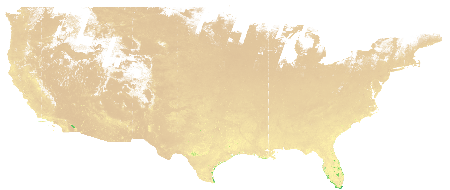

In [4]:
month = 1

image_url = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
    .mean()
    .visualize(min=0, max=180, palette=et_palette)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

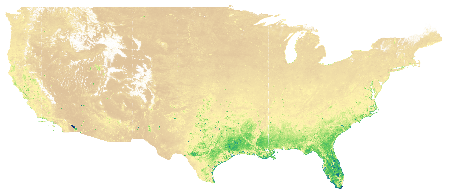

In [5]:
month = 3

image_url = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
    .mean()
    .visualize(min=0, max=180, palette=et_palette)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

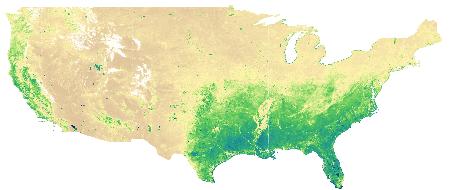

In [6]:
month = 4
climo_coll = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
)
image_url = (
    climo_coll.mean()
    .visualize(min=0, max=180, palette=et_palette)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

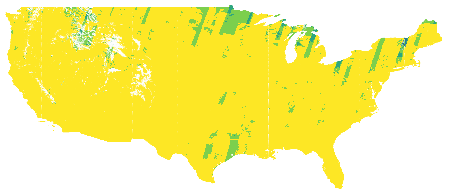

In [7]:
month = 4
climo_coll = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
)
image_url = (
    climo_coll.count()
    .visualize(min=0, max=5, palette=viridis)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png') 

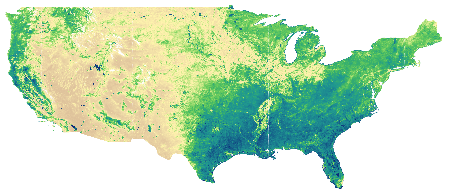

In [8]:
month = 5

image_url = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
    .mean()
    .visualize(min=0, max=180, palette=et_palette)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

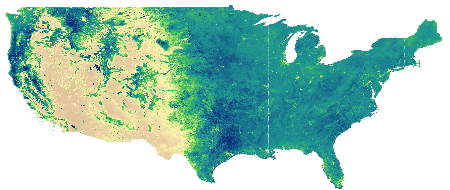

In [9]:
month = 7

image_url = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
    .mean()
    .visualize(min=0, max=200, palette=et_palette)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png')  

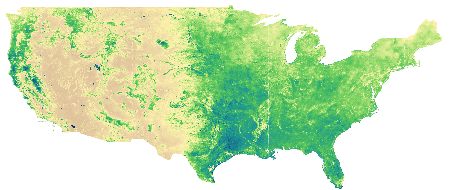

In [10]:
month = 9

image_url = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
    .mean()
    .visualize(min=0, max=180, palette=et_palette)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png') 

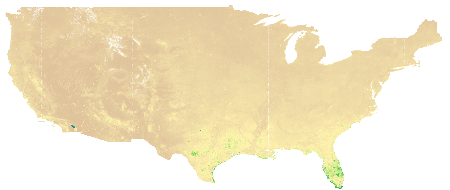

In [11]:
month = 11

image_url = (
    monthly_coll
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .filter(ee.Filter.calendarRange(month, month, 'month'))
    # .filterDate(f'{start_year}-01-01', f'{end_year+1}-01-01')
    .select(band_name)
    .mean()
    .visualize(min=0, max=180, palette=et_palette)
    .getThumbURL({'region': ee.Geometry.BBox(-125.5, 25, -66, 50), 'dimensions': 450})
)
Image(image_url, embed=True, format='png') 